## Library

In [1]:
from wass2s import *
import datetime
import importlib
from pathlib import Path
import warnings
import gc
warnings.filterwarnings("ignore")

#### Set forecast working directory

In [2]:
# Set forecast working directory
dir_s2s = "./PRCP_MAM_2025_ic_1/"
logopath = './utilities/cilss.png'#'./utilities/agrhymet_logo_combined_reversed.png'
fcst_labels = ["BELOW-AVERAGE", "NEAR-AVERAGE", "ABOVE-AVERAGE"]#["EN DESSOUS DE LA MOYENNE", "PROCHE DE LA MOYENNE", "AU DESSUS DE LA MOYENNE"]
dist_method="bestfit" # nonparam or bestfit

In [3]:
dir_s2s = Path(dir_s2s)
os.makedirs(dir_s2s, exist_ok=True)
### Save consolidated results
hdcst_consolidated = {}
hdcst_consolidated_prob = {}
fcst_consolidated = {}
fcst_consolidated_prob = {}
scores_consolidated = {}
### Save score
dir_save_score = f"{dir_s2s}/scores"
os.makedirs(dir_save_score, exist_ok=True)
### Save forecasts
dir_to_forecast = f"{dir_s2s}/forecasts"
os.makedirs(dir_to_forecast, exist_ok=True)

#### Set Climatological Years

In [4]:
# Set Climatological Years
clim_year_start = 1994 #1991
clim_year_end = 2016 #2020

## Download Observation and Process 


#### Load Downloader 

In [5]:
# Load WAS_S2S downloader class
downloader = WAS_Download()

In [6]:
# Filter observation names to identify precipitation-related models
variables_obs = [key for key in downloader.AgroObsName().keys() if "PRCP" in key]

# Specify the directory to save downloaded model data
dir_to_save_Obs = f"{dir_s2s}/Observation"

# choose sequence corresponding to seasonal forecast targets (JAS season in this case)
season_obs = ["03", "04", "05"]  # July-August-September forecast period

# Define the observation period (years 1993 to 2016)
year_start = 1991
year_end = 2025

# Set the bounding box for the area of interest (latitude and longitude bounds)
extent_obs = [12, -3.5, 4, 1.5]  # [Northern, Western, Southern and Eastern] 

# Specify whether to overwrite existing files when downloading data
force_download = False

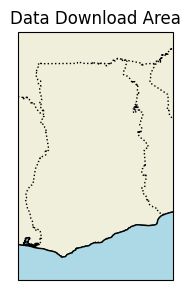

In [7]:
plot_map([extent_obs[1],extent_obs[3],extent_obs[2],extent_obs[0]], title="Data Download Area", fig_size=(4,3))

In [8]:
downloader.WAS_Download_AgroIndicators(
    dir_to_save_Obs,
    variables_obs,
    year_start,
    year_end,
    extent_obs,
    season_obs,
    force_download
)

PRCP_MAM_2025_ic_1/Observation/Obs_PRCP_1991_2025_MarAprMay.nc already exists. Skipping download.


In [9]:
#### Process predictant
rainfall = prepare_predictand(dir_to_save_Obs, variables_obs, year_start, year_end, season_obs, ds=False, daily=False)
season_str = "".join([calendar.month_abbr[int(month)] for month in season_obs])

#### Process Obs in combining with Seasonal cumulative Ground-Observation

In [10]:
# ## Path to the CPT file
cpt_input_file_path = "./MAM_1981-2025.csv"

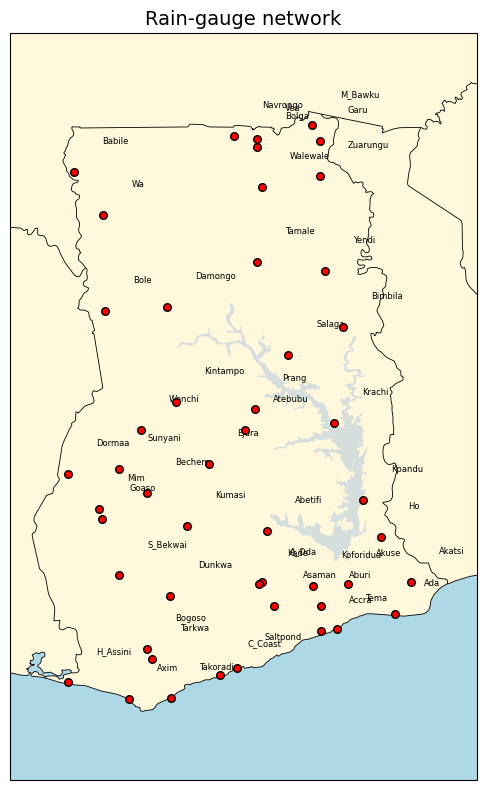

In [11]:
# ## Read CSV
df = pd.read_csv(cpt_input_file_path, na_values=-999.0,  encoding="latin1")
df_filtered = df[(df['STATION'] == 'LAT') | (df['STATION'] == 'LON') | 
                 (pd.to_numeric(df['STATION'], errors='coerce').between(year_start, year_end))]
verify_station_network(df_filtered, extent_obs)

In [12]:
da = prepare_predictand(dir_to_save_Obs, variables_obs, year_start, year_end, season_obs,  ds=False).sel(T=slice(str(year_start),str(year_end)))

In [13]:
### ## Instantiate WAS_Merging class
path_ = Path(dir_s2s / "rainfall_predictand_eval.nc")
data_merger = WAS_Merging(df_filtered, da, date_month_day= '04-01')
if path_.is_file():
    rainfall__ = xr.load_dataarray(path_)
else:
    rainfall__, _ = data_merger.simple_bias_adjustment(do_cross_validation=False)
    rainfall__.to_netcdf(path_)

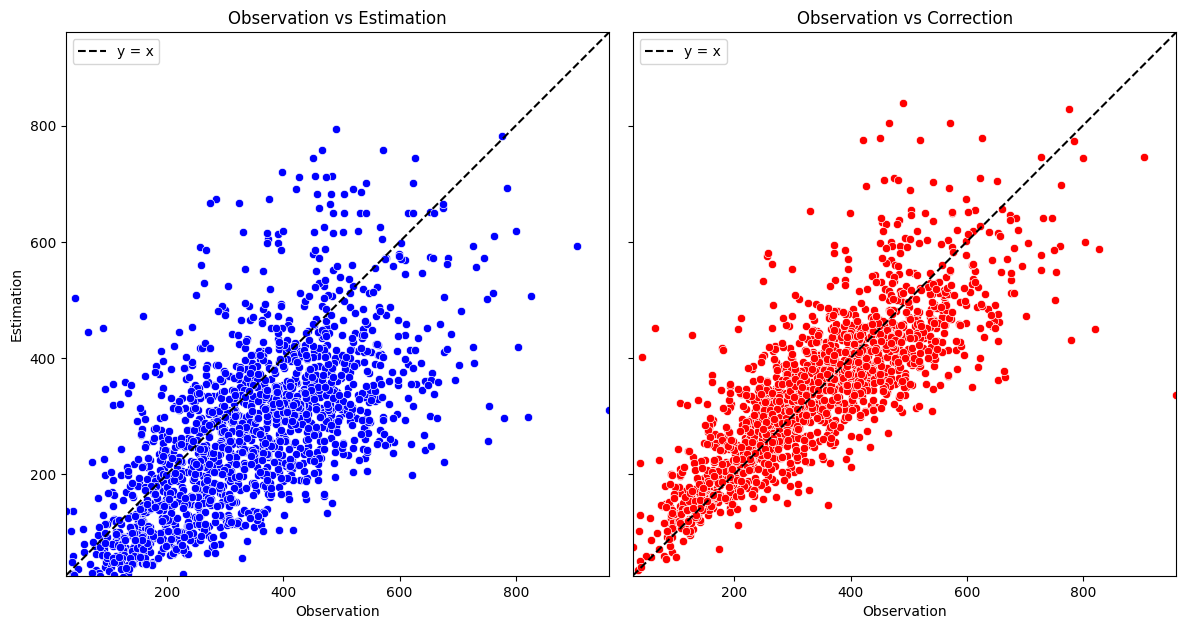

In [14]:
data_merger.plot_merging_comparaison(df_filtered, da, rainfall__)

In [15]:
rainfall = rainfall__
rainfall.name = "PRCP"

# Forecast

In [16]:
year = 2025

In [17]:
var = "PRCP"
season_str = "".join([calendar.month_abbr[int(month)] for month in season_obs])

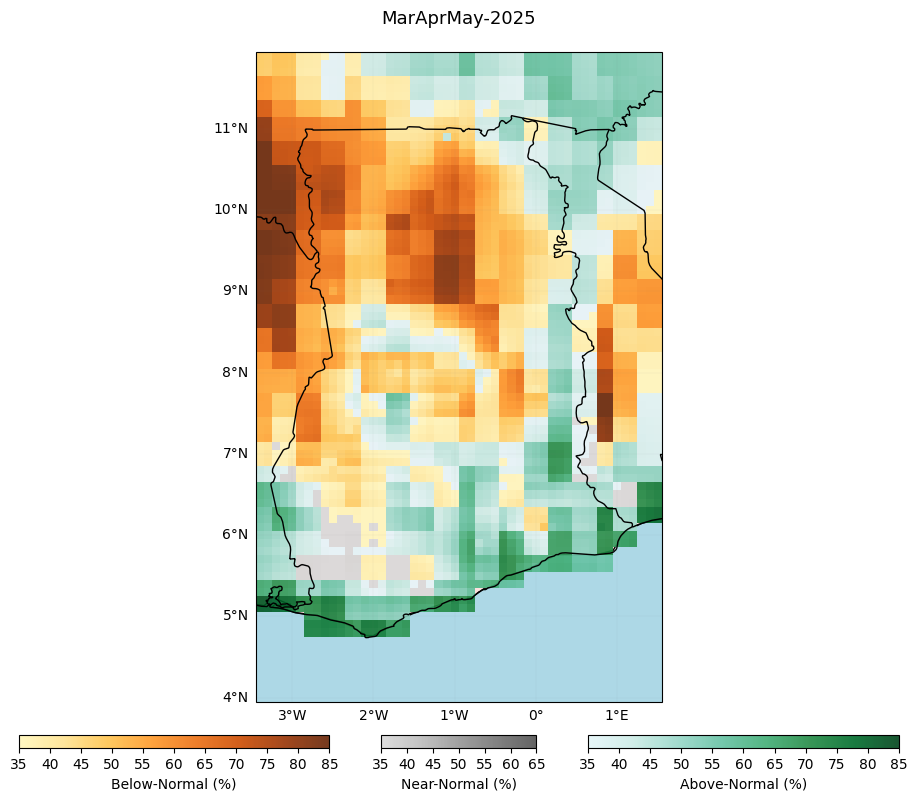

In [18]:
# forecast_det = xr.open_dataset(f'{dir_to_forecast}/Forecast_Det_{season_str}_{year}.nc')
forecast_prob = xr.open_dataset(f'{dir_to_forecast}/Forecast_Prob_{var}{season_str}_{year}.nc')
forecast_prob = forecast_prob.to_array().drop_vars('variable').squeeze('variable')
# forecast_det = forecast_det.to_array().drop_vars('variable').squeeze('variable')
plot_prob_forecasts_(dir_to_forecast, forecast_prob.drop_vars('T').squeeze(),
                    f"{season_str}-{year}", hspace=0.1, reverse_cmap=False)

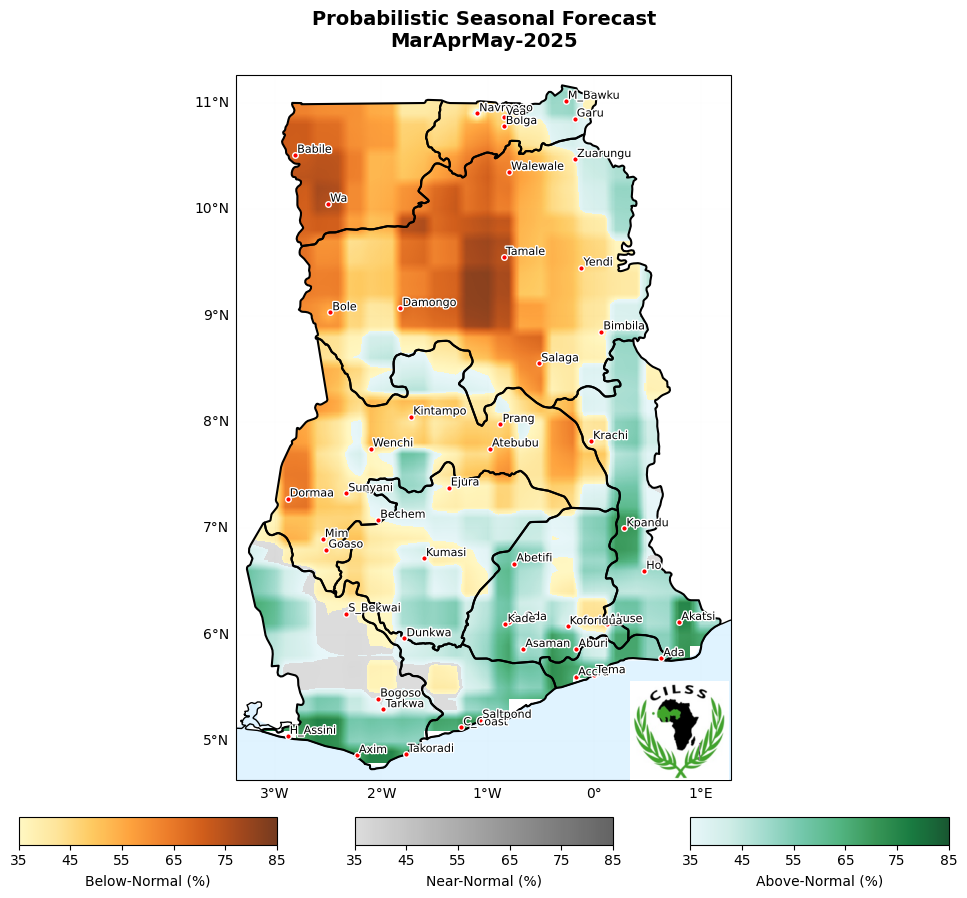

In [29]:
plot_prob_forecasts(
    dir_to_forecast,
    forecast_prob.isel(T=0).squeeze(), # Your xarray DataArray
    f"{season_str}-{year}",
    country_code="GHA",        # ISO3 code for Ghana
    source= "naturalearth",     # Lightweight source
    admin_level=1,             # Country level
    stations_df=df_filtered,    # Your station dataframe
    hspace=0.1,
    reverse_cmap=False,
    logo=logopath,
    logo_position='lower right',
    logo_size = ('21%', '14%'),
    res = 0.01
)

# Verification

In [20]:
was_verify = WAS_Verification(dist_method=dist_method)

### Ratio to average for Observed rainfall

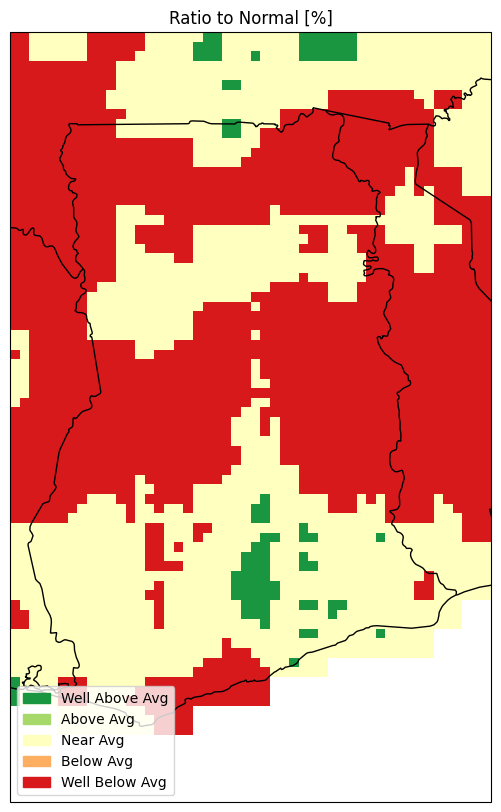

In [21]:
was_verify.ratio_to_average(rainfall, clim_year_start, clim_year_end, year)

### Terciles Oberved

In [22]:
%load_ext autoreload
%autoreload 2

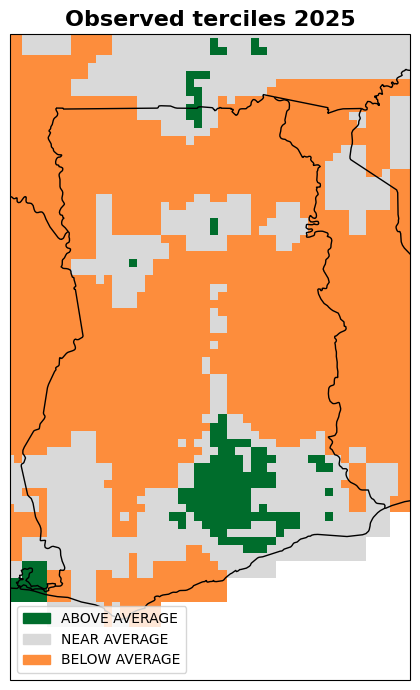

In [23]:
A = was_verify.compute_class(rainfall, clim_year_start, clim_year_end).sel(T=str(year))
plot_tercile(A, f"./Tercile_{year}", colors=['#fd8d3c', '#d9d9d9', '#006d2c'], year=2025)

### Ranked Probability Skill Score

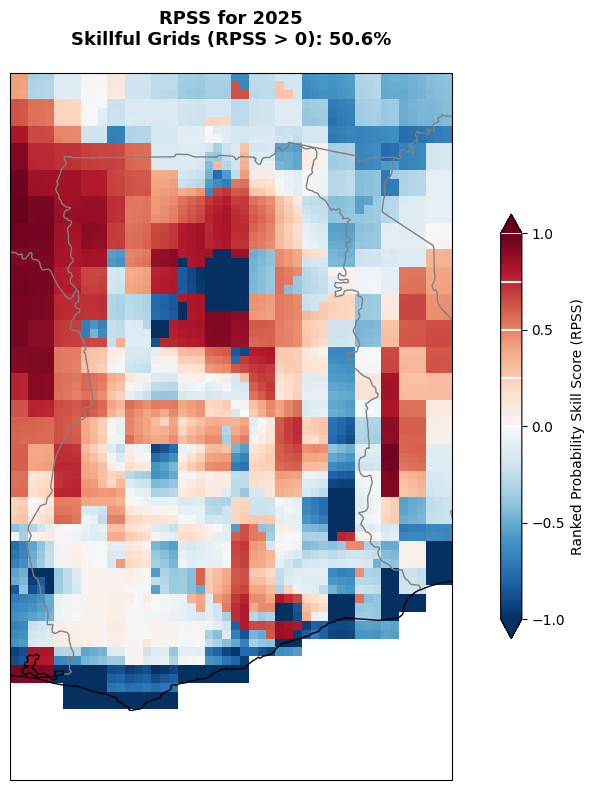

In [24]:
was_verify.compute_one_year_rpss(rainfall, forecast_prob, clim_year_start, clim_year_end, 2025)

In [25]:
# !jupyter nbconvert --to pdf --no-input ./01_Cumulative_Rainfall_Evaluation_2024.ipynb